### Student Name:Ashbah Faisal
### Student ID: 08271
### Student Email:af08271@st.habib.edu.pk

#### **Objectives**
This exam has two main objectives to achieve:
* Explore the heart disease dataset using exploratory data analysis (EDA)
* Exercise with Machine Learing Classification algorithms for prediction (modeling) 
---

**Instructions for Data Cleaning and Wrangling**:

* rows that have value `ca = 4` is incorrect. In the original dataset they are NaNs.
* rows that have value `thal = 0` is also incorrect. They are also NaNs in the original dataset.

**Action**:  Drop the incorrect rows above. Please report the total number of rows **before and after** cleaning for verification.

---

**Instructions for Exploratory Data Analysis**:

* your target/class column is `heart_disease`
* 3 exploratory data analysis (EDA) and visualization for `Only Numerical Features`. Use different EDA methods and visualization types (example: density/distribution plot, scatter plot, correlation plot etc). Use different combination of columns/features.
* 3 exploratory data analysis (EDA) and visualization for `Categorical Features Only (or pair of numerical/categorical columns)`. Use different EDA methods and visualization types (example: count distribution plot, group by table, box plot etc). Use different combination of columns/features. For categorical column, you can also use target/class column.

**Action**:  For each EDA result/visualization, briefly explain the insights. **EDA without explanation will not be accepted.**

---

**Instructions for Machine Learning**:

* your target/class column is `heart_disease`
* build 2 different machine learning models for classification. Use encoding when needed.
* you can use any of the classification alorithms from the sklearn libarary such as `Logistic Regression`, `Nearest Neighbors`, `Support Vectors`, `Nu SVC`, `Decision Tree`, `Random Forest`, `AdaBoost`, `Gradient Boosting`, `Naive Bayes`, `Linear Discriminant Analysis`, `Quadratic Discriminant Analysis` and `Neural Net`.
* use classification accuracy, precision, recall and confusion matrix to evaluate models and compare them.

**Action**:  Briefly compare the above machine learning models. **Results without explanation will not be accepted.**

---

**Instructions for Improving Machine Learning model**:

* pick any of the above machine learning model and try to improve the classification accuracy
* you can apply any method such as pruning, feature selection (using only important features) or any parameter tuning to improve the model.

**Action**:  Briefly explain your approach and discuss if it improves the classification accuracy. **Results without explanation will not be accepted.**

---

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import pandas as pd
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt


In [6]:
df = pd.read_csv('heart_disease_data.csv')

# Check total number of rows before cleaning
print("Total rows before cleaning:", df.shape[0])


Total rows before cleaning: 303


In [121]:

df_cleaned = df[(df['ca'] != 4) & (df['thal'] != 0)]
print(df_cleaned[(df_cleaned['ca'] == 4)])
print(df_cleaned[(df_cleaned['thal'] == 0)])
print(df_cleaned)

Empty DataFrame
Columns: [age, sex, cp, trest_blood_pressure, chol, fasting_blood_sugar, rest_ecg, thal_ach, exang, old_peak, slope, ca, thal, heart_disease]
Index: []
Empty DataFrame
Columns: [age, sex, cp, trest_blood_pressure, chol, fasting_blood_sugar, rest_ecg, thal_ach, exang, old_peak, slope, ca, thal, heart_disease]
Index: []
     age     sex  cp  trest_blood_pressure  chol fasting_blood_sugar  \
0     63    male   3                   145   233                high   
1     37    male   2                   130   250              normal   
2     41  female   1                   130   204              normal   
3     56    male   1                   120   236              normal   
4     57  female   0                   120   354              normal   
..   ...     ...  ..                   ...   ...                 ...   
298   57  female   0                   140   241              normal   
299   45    male   3                   110   264              normal   
300   68    male

In [10]:
print("Total rows after cleaning:", df_cleaned.shape[0])

Total rows after cleaning: 296


In [12]:
print(df_cleaned.isnull().sum())

age                     0
sex                     0
cp                      0
trest_blood_pressure    0
chol                    0
fasting_blood_sugar     0
rest_ecg                0
thal_ach                0
exang                   0
old_peak                0
slope                   0
ca                      0
thal                    0
heart_disease           0
dtype: int64


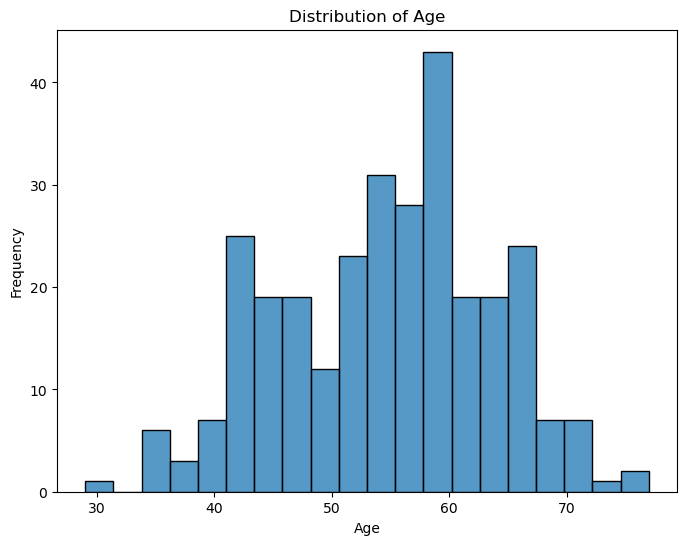

In [18]:
#1:distribution of Age
plt.figure(figsize=(8, 6))
sns.histplot(df_cleaned['age'], bins=20)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()


### Analysis
comparing the age bracket and the number of people of this age bracket suffering from heart diseases. Here the histogram shows that people in the age brackrt of 50-60 suffer the most from heart diseas this is because young people are healthier nad the number of people alive post 60 decreases.

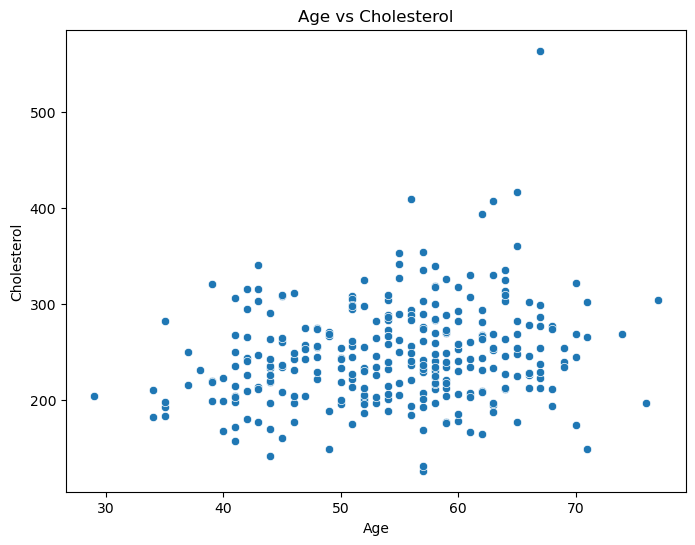

In [20]:
#2: Scatter plot of Age vs Cholesterol
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df_cleaned['age'], y=df_cleaned['chol'])
plt.title('Age vs Cholesterol')
plt.xlabel('Age')
plt.ylabel('Cholesterol')
plt.show()



### Analysis
The scatter plot compares the age with cholestrol i.e the which age bracket suffers the with the highest or lowest cholestrol. Here the highest cholestrol is above 500 in the age bracjket of 60-70 while the lowest cholestrol is less than 100 which is in the age bracket of 50-60. This shows taht people start sufferng from cholestrol issues post the age of 50

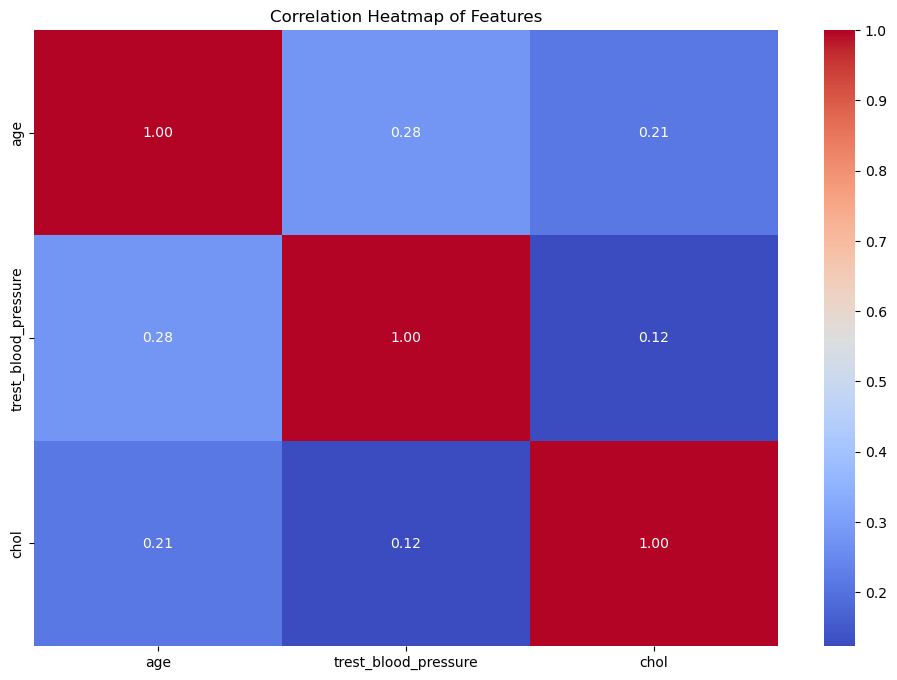

In [125]:
#3: Correlation Heatmap
continuous_columns = ['age', 'trest_blood_pressure', 'chol']
corr_matrix = df[continuous_columns].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Features')
plt.show()


### Analysis
This shows the correalation between age and cholestrol whixh is 0.21 i.e pretty high it also shows the correalation of blood pressure with age which is 0.12 also high but lower compared to ags eith cholestrol. cholestrol and blood pressure also have a good correalation i.e decent.

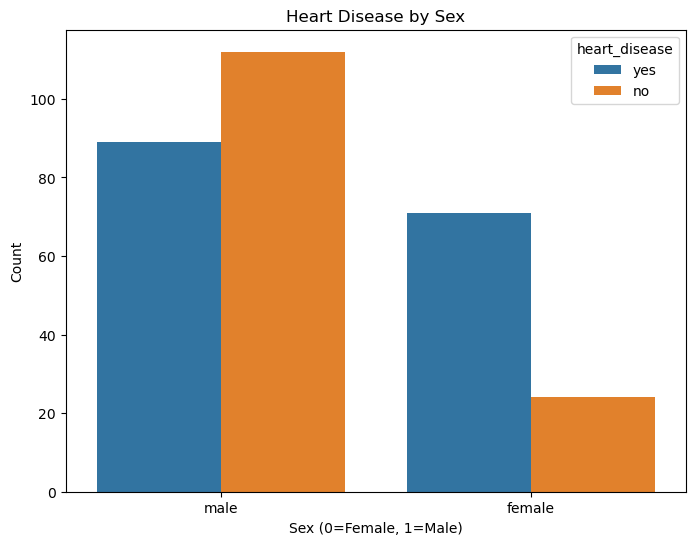

In [26]:
#Categorical
# 1: Count Plot for Heart Disease by Sex
plt.figure(figsize=(8, 6))
sns.countplot(data=df_cleaned, x='sex', hue='heart_disease')
plt.title('Heart Disease by Sex')
plt.xlabel('Sex (0=Female, 1=Male)')
plt.ylabel('Count')
plt.show()

### Analysis 
firstly the graph above shows that there are more males than females than it shows that compared to males who have heart dises males who dn't have heart dises is higher. Furthermore females who have heart diseas are higher than females who don't have heart diseas.But males with heart disease is more than females with heart disease

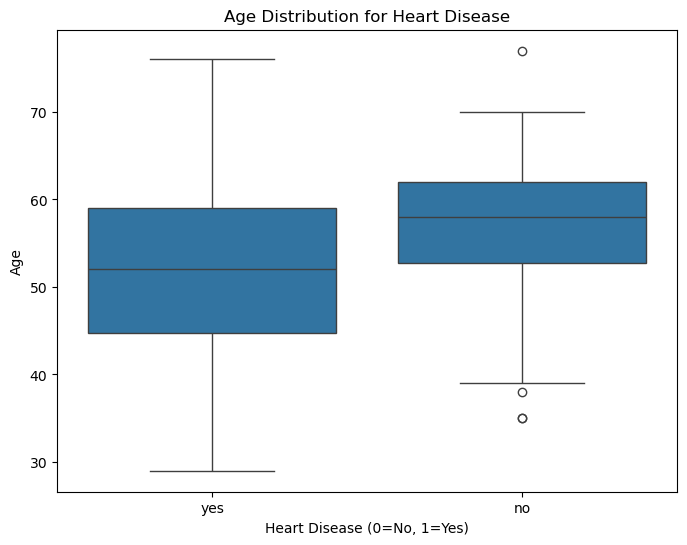

In [144]:
#2: Boxplot for Age and Heart Disease
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_cleaned, x='heart_disease', y='age')
plt.title('Age Distribution for Heart Disease')
plt.xlabel('Heart Disease (0=No, 1=Yes)')
plt.ylabel('Age')
plt.show()

### Analysis
The box plot indicates that the median age of individuals with heart disease is slightly lower compared to people who don't have a heart disease as the median age for people with heart disease is around 50 while for people who don't havea heart disease is around 60.

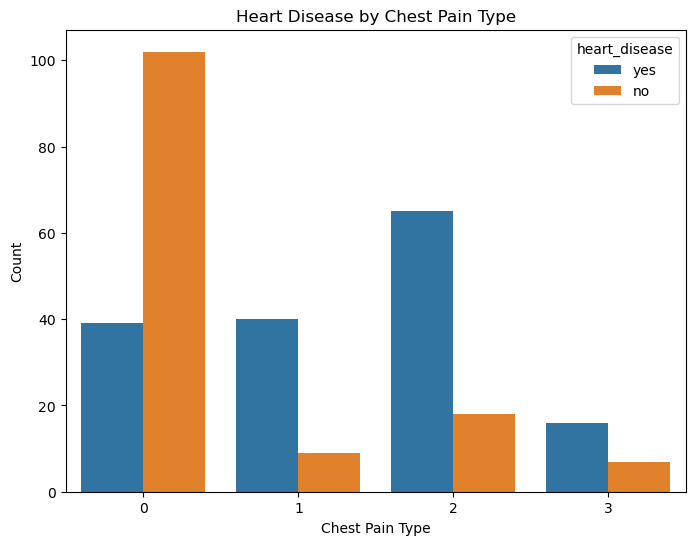

In [32]:
#3: Count Plot for Heart Disease by Chest Pain Type
plt.figure(figsize=(8, 6))
sns.countplot(data=df_cleaned, x='cp', hue='heart_disease')
plt.title('Heart Disease by Chest Pain Type')
plt.xlabel('Chest Pain Type')
plt.ylabel('Count')
plt.show()

### Analysis
This histogram copares the people who have chest pain of level 1 with otherc levels this indicates that people with chest pain of level 2 are mostly suffering from heart disese while peoplw ith chest pain of level 1 are relatively less no. of ppl who suffer from heat disease.

In [74]:
# machine learning 
X = df_cleaned.drop(['heart_disease'], axis=1)
y = df_cleaned['heart_disease']
y = y.replace({'yes': 1, 'no': 0})
X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=99)


C:\Users\cw\AppData\Local\Temp\ipykernel_2344\2037702627.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = y.replace({'yes': 1, 'no': 0})


In [154]:
#1: Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Classifier Results:")
print(f"Accuracy: {accuracy_dt:.4f}")

Decision Tree Classifier Results:
Accuracy: 0.7500


n_estimators: 10, Test Accuracy: 83.33%
n_estimators: 50, Test Accuracy: 85.00%
n_estimators: 100, Test Accuracy: 85.00%
n_estimators: 150, Test Accuracy: 85.00%
n_estimators: 200, Test Accuracy: 85.00%


Text(0.5, 0, 'Random Forest Feature Importance')

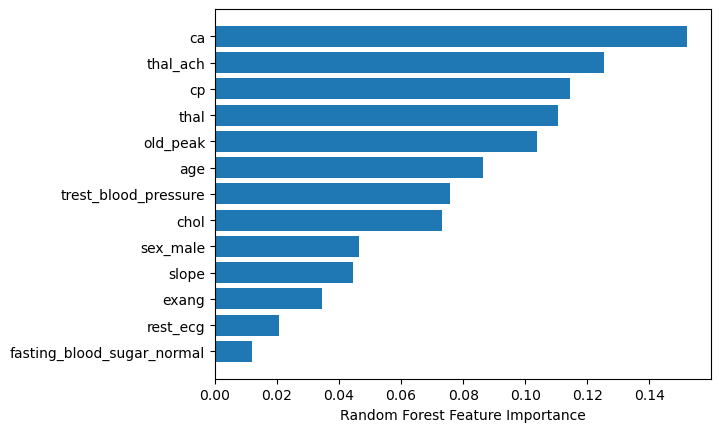

In [152]:
#2: Random Forest
n_estimators_values = [10, 50, 100, 150, 200]
results = {}  

for n in n_estimators_values:
    rf_model = RandomForestClassifier(n_estimators=n, random_state=99)
    rf_model.fit(X_train, y_train)
    
    test_pred = rf_model.predict(X_test)
    
    acc = accuracy_score(y_test, test_pred) * 100

    print(f'n_estimators: {n}, Test Accuracy: {acc:.2f}%')

best_rf_model = RandomForestClassifier(n_estimators=150, random_state=99)
best_rf_model.fit(X_train, y_train)

feature_importances =best_rf_model.feature_importances_
sorted_idx = best_rf_model.feature_importances_.argsort()

#plt.barh(list(X.columns), feature_importances)
plt.barh(list(X.columns[sorted_idx]),feature_importances[sorted_idx])
plt.xlabel("Random Forest Feature Importance")

### evaluation 
Accuracy:
The Decision Tree model outperforms the Random Forest model in terms of accuracy (75% vs 40%).
The Random Forest model’s lower accuracy suggests it might be struggling with overfitting or might not be suited for this particular dataset.
This could be possible because random tree might be missing on a lot of true positive cases.
Decision Tree appears to be the better model in this case based on the provided metrics. It has a higher accuracy
Random Forest might be overfitting or not well-tuned for this dataset, leading to a higher number of false negatives and false positives.

train accuracy  100.0
test accuracy 73.33333333333333


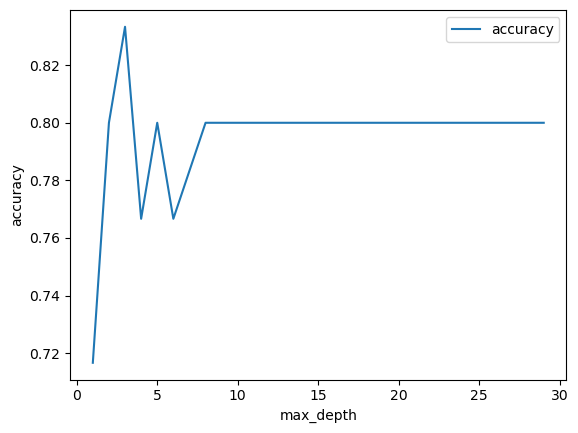

In [107]:
dt = tree.DecisionTreeClassifier(criterion='entropy',random_state=99)
dtmodel = dt.fit(X_train, y_train)
train_pred = dtmodel.predict(X_train)
acc = accuracy_score(train_pred, y_train)
print("train accuracy ",acc*100)

test_pred = dtmodel.predict(X_test)
acc = accuracy_score(test_pred, y_test)
print("test accuracy",acc*100)

max_depth = []
acc = []
for i in range(1,30):
    dtree = tree.DecisionTreeClassifier(max_depth=i,random_state=100)
    dtree.fit(X_train, y_train)
    pred = dtree.predict(X_test)
    acc.append(accuracy_score(y_test, pred))
    max_depth.append(i)
    
d = pd.DataFrame({'accuracy':pd.Series(acc),'max_depth':pd.Series(max_depth)})

# visualizing changes in parameters
plt.plot(d['max_depth'].values,d['accuracy'].values)
plt.xlabel('max_depth')
plt.ylabel('accuracy')
plt.legend(["accuracy"])



#### Analysis
Very high training set accuracy is a sign of Model Overfitting (see lecture notes). It means model focused too much on training set that it fails to generalize the relationship for test set and here the train set is 100 so lets prun it.

Train Accuracy: 88.14%
Test Accuracy: 78.33%


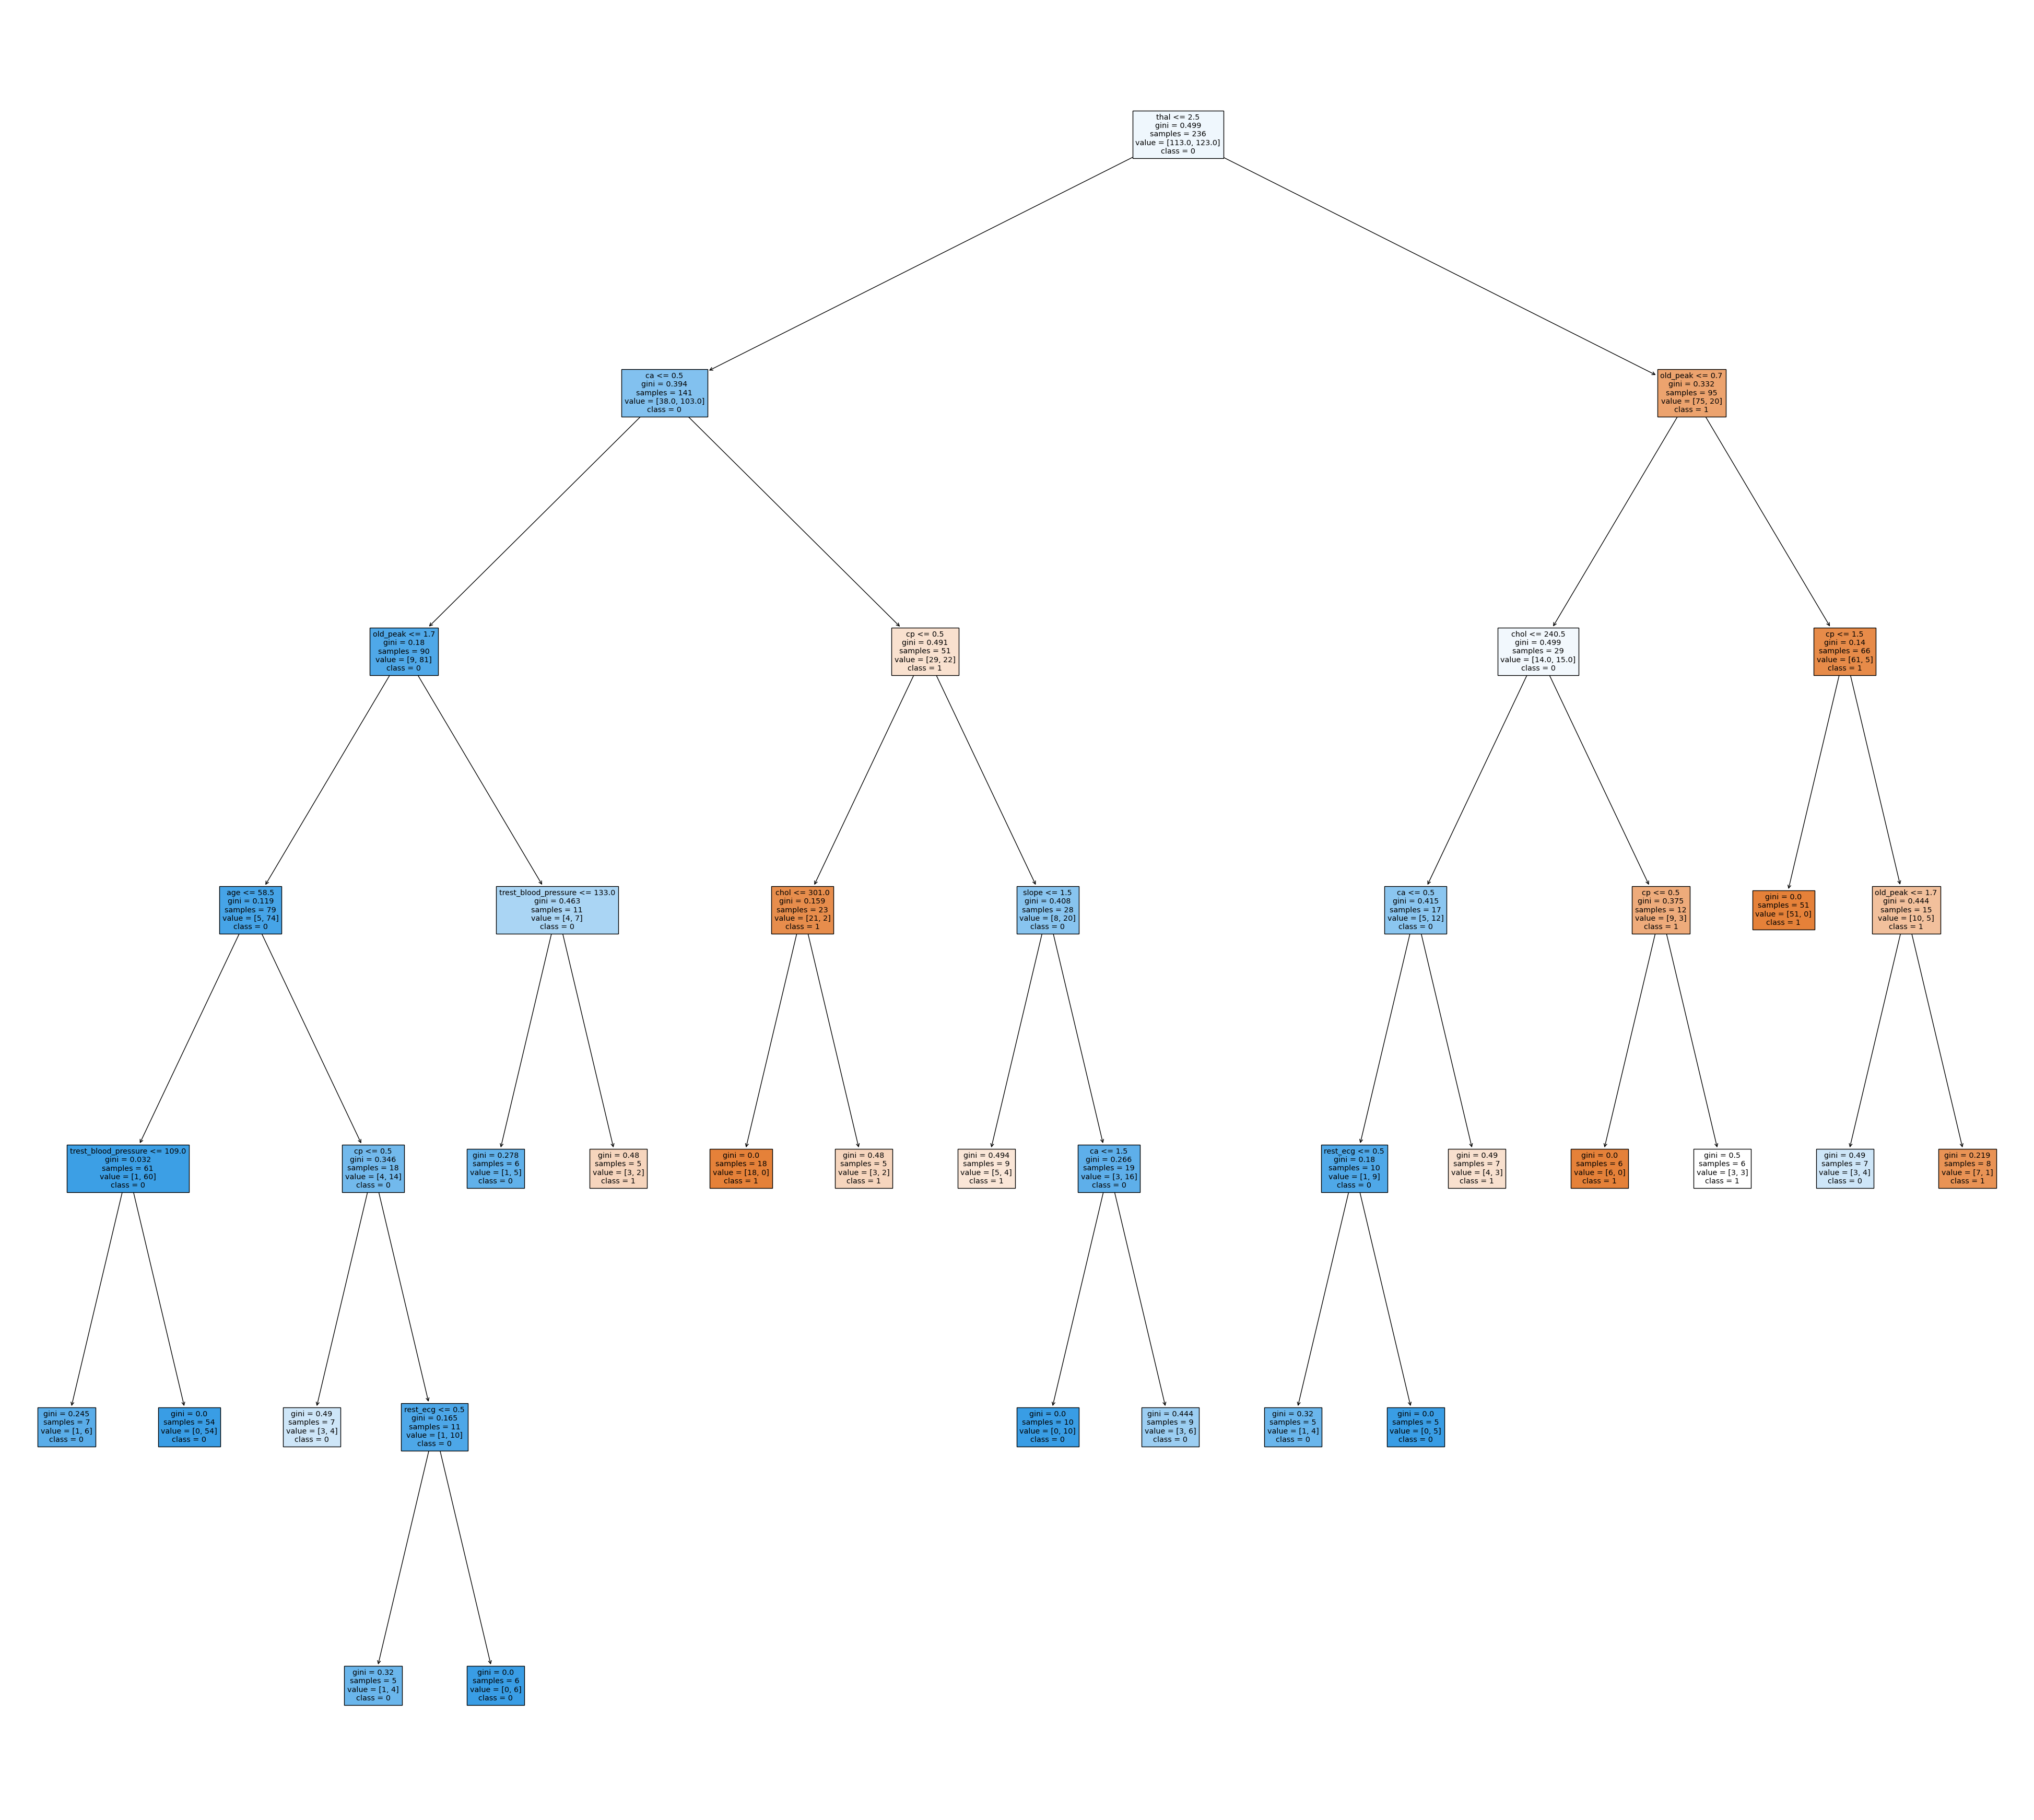

In [162]:
# Building the pruned Decision Tree model
dt = tree.DecisionTreeClassifier(
    criterion='gini',               # Using Gini impurity
    max_depth=6,                    # Limiting tree depth to 6 to avoid overfitting
    min_samples_split=10,           # Minimum samples required to split a node
    min_samples_leaf=5,             # Minimum samples required to be at a leaf node
    random_state=99
)
dtmodel = dt.fit(X_train, y_train)

train_pred = dtmodel.predict(X_train)
train_acc = accuracy_score(y_train, train_pred)
print(f"Train Accuracy: {train_acc*100:.2f}%")

test_pred = dtmodel.predict(X_test)
test_acc = accuracy_score(y_test, test_pred)
print(f"Test Accuracy: {test_acc*100:.2f}%")

fig = plt.figure(figsize=(50, 45))
_ = tree.plot_tree(dtmodel, 
                   feature_names=list(X.columns),  
                   class_names=list(map(str, y.value_counts().index)),  # Ensuring class names are strings
                   filled=True)
plt.show()


### Analysis
As shown that the accuracy of the training set is not 100% i.e the model is less over fitted. The pruned model is less complex as shown in the tree above compared to the previous one. The pruned helped increase accuracy on the test data.